### 1. Initialize Environment & Dual Agents

In [ ]:
import os
from env import HouseholdEnvironment
from agents import DM_agent, ME_agent, MemoryEncoding

# Read OPENAI_API_KEY from environment
os.environ["OPENAI_API_KEY"] = "YOUR_API_KEY"
api_key = os.getenv("OPENAI_API_KEY")

llm_config = {
    "model_id": "gpt-5-mini",
    "temperature": 0.0,
    "max_tokens": 1024,
}

# 1. Initialize environment
env = HouseholdEnvironment()

# 2. Decision-Making Agent & Memory Encoding Agent
dm_agent = DM_agent(**llm_config)
me_agent = ME_agent(**llm_config)
memory_encoding = MemoryEncoding(me_agent=me_agent)

/Users/jongchan/anaconda3/envs/hfes26/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LLM_gpt initialized with model: gpt-5-mini
LLM_gpt initialized with model: gpt-5-mini


### 2. Run Dual-Agent Execution Loop & Save Messages/Video

Task Description: You have entered floorplan2. You can go to fridge, sink, table 1, microwave, stove, table 2, and door. The exploration task begins. Your first subtask is to: Explore the position 'fridge'.
Assistant 1: Belief: I am at the starting location in floorplan2. I have not yet explored the fridge position.
Desire: Explore the position 'fridge'.
Intention: go to fridge
Observation 1 (4.46s -): You arrive at fridge. Looking around you, you see a fridge 1. You completed subtask 1. Your next subtask is to: Explore the position 'table 1'.
--------------------------------------------------
Assistant 2: Belief: I am at the fridge and the fridge position is explored. Table 1 has not yet been explored.
Desire: Explore the position 'table 1'.
Intention: go to table 1
Observation 2 (8.92s -): You arrive at table 1. On the countertop 2, you see a tomato 1, a mug 1, an egg 1, and a bread 1. You completed subtask 2. Your next subtask is to: Explore the position 'sink'.
--------------------

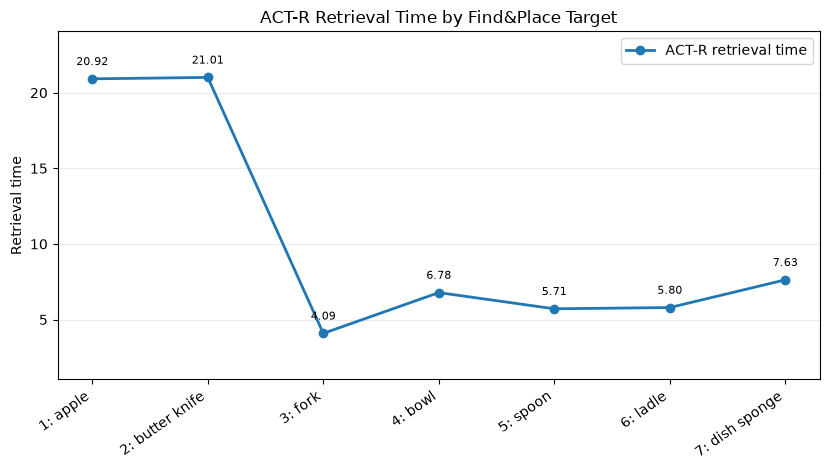

Saved ACT-R retrieval time plot: actr_retrieval_times.png


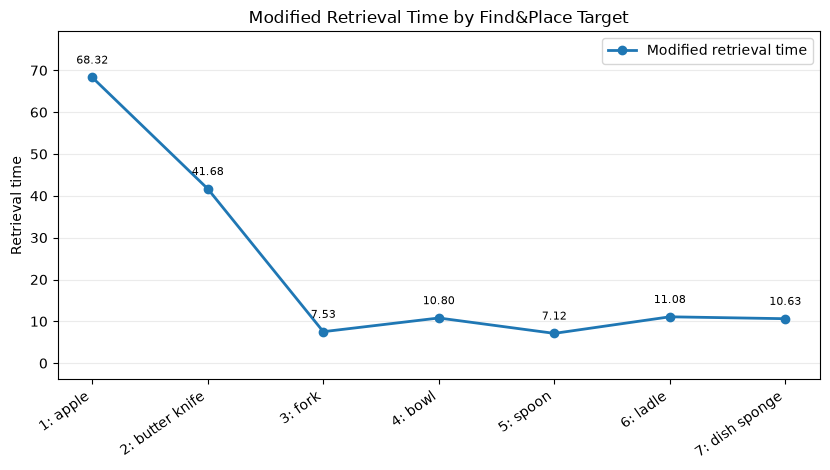

Saved modified retrieval time plot: modified_retrieval_times.png


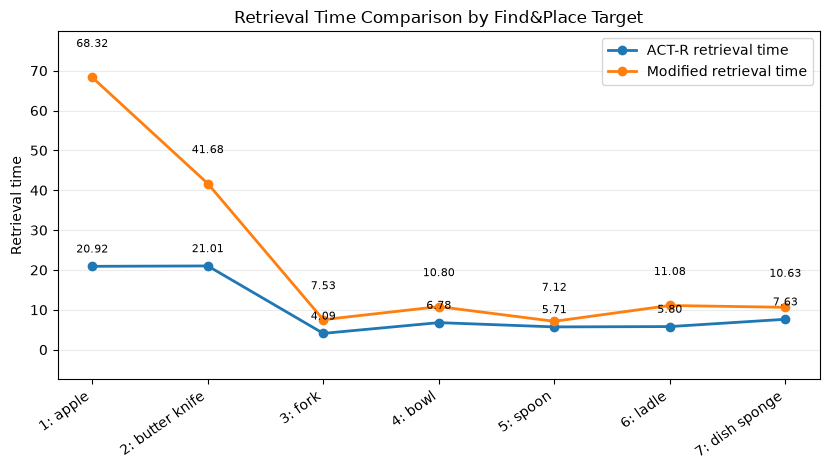

Saved combined retrieval time plot: combined_retrieval_times.png
🎬 Saved execution video animation: video.gif
✓ All artifacts successfully saved!


In [ ]:
from module import run_agent_loop

# Run dual-agent interaction loop and export messages & execution video
results = run_agent_loop(
    env=env,
    dm_agent=dm_agent,
    memory_encoding=memory_encoding,
    debug = False, 
    print_summary = False, 
    display_retrieval_plots=True,   
    save_video=True,
    save_chat=True,
    output_video_path="video.gif",
    output_messages_path="chat.json",
)